# Data Preprocessing Phase 2 — Shared Features

Notebook nay tao ra cac bang feature dung chung cho ca team.

Diem da duoc sua de notebook chay on dinh hon:
- Neu `data/clean/*.parquet` chua ton tai, notebook se tu fallback ve raw CSV.
- Neu may chua co engine doc/ghi parquet (`pyarrow` / `fastparquet`), notebook se khong vo ngay.
- Cac cot ngay thang se duoc chuan hoa lai de tranh loi dtype.
- Co thong bao ro rang dang doc tu CLEAN hay RAW.


In [10]:
import warnings
from importlib.util import find_spec
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

def find_project_root():
    cwd = Path.cwd().resolve()
    candidate_roots = [cwd, *cwd.parents]
    candidate_roots.extend(path for path in cwd.iterdir() if path.is_dir())
    for candidate in candidate_roots:
        if (candidate / 'datathon-2026-round-1').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError(
        "Khong tim thay thu muc project chua `datathon-2026-round-1/` va `data/`. "
        "Hay mo notebook tu `VinDatathon_the-4-Outliers` hoac repo root."
    )

def detect_parquet_engine():
    if find_spec('pyarrow') is not None:
        return 'pyarrow'
    if find_spec('fastparquet') is not None:
        return 'fastparquet'
    return None

ROOT = find_project_root()
RAW_DIR = ROOT / 'datathon-2026-round-1'
CLEAN_DIR = ROOT / 'data' / 'clean'
FEATURE_DIR = ROOT / 'data' / 'features'
FEATURE_DIR.mkdir(parents=True, exist_ok=True)
PARQUET_ENGINE = detect_parquet_engine()
PARQUET_NOTICE_SHOWN = False

print(f'[INFO] Project root: {ROOT}')
if PARQUET_ENGINE is None:
    print('[INFO] Khong co pyarrow/fastparquet -> notebook se doc CSV va ghi pickle khi can.')
else:
    print(f'[INFO] Parquet engine: {PARQUET_ENGINE}')

DATE_COLUMNS_RAW = {
    'customers': ['signup_date'],
    'promotions': ['start_date', 'end_date'],
    'orders': ['order_date'],
    'shipments': ['ship_date', 'delivery_date'],
    'returns': ['return_date'],
    'reviews': ['review_date'],
    'sales': ['Date'],
    'inventory': ['snapshot_date'],
    'web_traffic': ['date'],
}


[INFO] Project root: D:\B. COMPUTER SCIENCE PROJECTS\D. DATATHON\VinDatathon_the-4-Outliers
[INFO] Parquet engine: pyarrow


In [11]:
def read_raw(name):
    df = pd.read_csv(RAW_DIR / f'{name}.csv', parse_dates=DATE_COLUMNS_RAW.get(name))
    if name == 'sales' and 'Date' in df.columns:
        df = df.rename(columns={'Date': 'date'})
    return df

def note_missing_parquet_support():
    global PARQUET_NOTICE_SHOWN
    if not PARQUET_NOTICE_SHOWN:
        print('[INFO] Pyarrow/fastparquet chua duoc cai -> bo qua parquet cho toan notebook.')
        PARQUET_NOTICE_SHOWN = True

def read_clean_or_raw(name):
    parquet_path = CLEAN_DIR / f'{name}.parquet'
    if parquet_path.exists() and PARQUET_ENGINE is not None:
        try:
            df = pd.read_parquet(parquet_path, engine=PARQUET_ENGINE)
            print(f'[OK] Doc CLEAN parquet: {name}')
            return df
        except Exception as e:
            print(f'[WARN] Doc parquet loi voi {name}: {e}')
            print(f'[FALLBACK] Chuyen sang doc RAW CSV cho {name}')
            return read_raw(name)
    if parquet_path.exists():
        note_missing_parquet_support()
        print(f'[FALLBACK] Bo qua CLEAN parquet, doc RAW CSV cho {name}')
        return read_raw(name)
    print(f'[FALLBACK] Khong tim thay CLEAN parquet, doc RAW CSV cho {name}')
    return read_raw(name)

def save_feature(df, name):
    parquet_path = FEATURE_DIR / f'{name}.parquet'
    if PARQUET_ENGINE is not None:
        try:
            df.to_parquet(parquet_path, index=False, engine=PARQUET_ENGINE)
            return {'dataset': name, 'path': str(parquet_path), 'format': 'parquet'}
        except Exception as e:
            print(f'[WARN] Ghi parquet loi voi {name}: {e}')
    else:
        note_missing_parquet_support()
    fallback_path = FEATURE_DIR / f'{name}.pkl'
    df.to_pickle(fallback_path)
    print(f'[FALLBACK] Da ghi tam bang pickle: {fallback_path.name}')
    return {'dataset': name, 'path': str(fallback_path), 'format': 'pickle'}

def nearest_future_event_days(dates, event_dates):
    event_dates = pd.to_datetime(pd.Series(sorted(pd.to_datetime(event_dates).unique())))
    result = []
    for d in pd.to_datetime(dates):
        future = event_dates[event_dates >= d]
        if len(future) == 0:
            result.append(np.nan)
        else:
            result.append(int((future.iloc[0] - d).days))
    return result

def _as_datetime_series(dates):
    if isinstance(dates, pd.Series):
        return pd.to_datetime(dates)
    return pd.Series(pd.to_datetime(dates))

def _event_index(event_dates):
    return pd.DatetimeIndex(pd.to_datetime(pd.Series(event_dates).dropna()).unique()).sort_values()

def days_since_previous_event(dates, event_dates):
    date_series = _as_datetime_series(dates)
    event_dates = _event_index(event_dates)
    result = []
    for d in date_series:
        previous = event_dates[event_dates <= d]
        if len(previous) == 0:
            result.append(np.nan)
        else:
            result.append(int((d - previous[-1]).days))
    return pd.Series(result, index=date_series.index)

def event_window_flag(dates, event_dates, start_offset, end_offset):
    date_series = _as_datetime_series(dates)
    event_dates = _event_index(event_dates)
    flag = pd.Series(False, index=date_series.index)
    for event_date in event_dates:
        start_date = event_date + pd.Timedelta(days=start_offset)
        end_date = event_date + pd.Timedelta(days=end_offset)
        flag = flag | date_series.between(start_date, end_date)
    return flag.astype('int8')


## 1. Doc du lieu dau vao

Notebook uu tien doc du lieu da clean o Layer 1.
Neu chua co thi se quay ve raw CSV de notebook van chay duoc.


In [12]:
products = read_clean_or_raw('products')
orders = read_clean_or_raw('orders')
order_items = read_clean_or_raw('order_items')
payments = read_clean_or_raw('payments')
returns = read_clean_or_raw('returns')
sales = read_clean_or_raw('sales')
web_traffic = read_clean_or_raw('web_traffic')
shipments = read_clean_or_raw('shipments')

# Chuan hoa lai date de dam bao khi fallback tu raw thi van groupby / merge duoc.
if 'date' not in sales.columns and 'Date' in sales.columns:
    sales = sales.rename(columns={'Date': 'date'})

sales['date'] = pd.to_datetime(sales['date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
returns['return_date'] = pd.to_datetime(returns['return_date'])
web_traffic['date'] = pd.to_datetime(web_traffic['date'])
shipments['ship_date'] = pd.to_datetime(shipments.get('ship_date'), errors='coerce')
shipments['delivery_date'] = pd.to_datetime(shipments.get('delivery_date'), errors='coerce')
for col in ['order_id', 'shipping_fee']:
    if col in shipments.columns:
        shipments[col] = pd.to_numeric(shipments[col], errors='coerce')

for col in ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount']:
    if col in order_items.columns:
        order_items[col] = pd.to_numeric(order_items[col], errors='coerce')

for col in ['order_id', 'customer_id']:
    if col in orders.columns:
        orders[col] = pd.to_numeric(orders[col], errors='coerce')

for col in ['product_id', 'price', 'cogs']:
    if col in products.columns:
        products[col] = pd.to_numeric(products[col], errors='coerce')

for col in ['order_id', 'payment_value', 'installments']:
    if col in payments.columns:
        payments[col] = pd.to_numeric(payments[col], errors='coerce')

for col in ['refund_amount']:
    if col in returns.columns:
        returns[col] = pd.to_numeric(returns[col], errors='coerce')

for col in ['Revenue', 'COGS']:
    if col in sales.columns:
        sales[col] = pd.to_numeric(sales[col], errors='coerce')

input_shape = pd.DataFrame([
    {'table': 'products', 'rows': len(products), 'cols': products.shape[1]},
    {'table': 'orders', 'rows': len(orders), 'cols': orders.shape[1]},
    {'table': 'order_items', 'rows': len(order_items), 'cols': order_items.shape[1]},
    {'table': 'payments', 'rows': len(payments), 'cols': payments.shape[1]},
    {'table': 'returns', 'rows': len(returns), 'cols': returns.shape[1]},
    {'table': 'sales', 'rows': len(sales), 'cols': sales.shape[1]},
    {'table': 'web_traffic', 'rows': len(web_traffic), 'cols': web_traffic.shape[1]},
    {'table': 'shipments', 'rows': len(shipments), 'cols': shipments.shape[1]}
])
input_shape


[OK] Doc CLEAN parquet: products
[OK] Doc CLEAN parquet: orders
[OK] Doc CLEAN parquet: order_items
[OK] Doc CLEAN parquet: payments
[OK] Doc CLEAN parquet: returns
[OK] Doc CLEAN parquet: sales
[OK] Doc CLEAN parquet: web_traffic
[OK] Doc CLEAN parquet: shipments


,table,rows,cols
0,products,2412,8
1,orders,646945,8
2,order_items,714669,7
3,payments,646945,4
4,returns,39939,7
5,sales,3833,3
6,web_traffic,3652,7
7,shipments,566067,4


## 2. Shared line items

Bang nay dung chung cho product analysis, margin analysis, pricing, promotion.


In [13]:
shared_line_items = (
    order_items
    .merge(
        orders[['order_id', 'order_date', 'customer_id', 'order_status', 'payment_method', 'device_type', 'order_source']],
        on='order_id', how='left'
    )
    .merge(
        products[['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']],
        on='product_id', how='left'
    )
    .merge(
        payments[['order_id', 'payment_value', 'installments']],
        on='order_id', how='left'
    )
    .merge(
        shipments[['order_id', 'shipping_fee']],
        on='order_id', how='left'
    )
)

# ======================================================================
# WARNING: order-level columns repeated on line-item grain
# ----------------------------------------------------------------------
# payment_value, installments, shipping_fee la cot cap ORDER, nhung da
# duoc merge xuong shared_line_items, noi 1 dong = 1 san pham trong order.
# Vi vay KHONG duoc sum truc tiep cac cot nay tren shared_line_items.
# Neu can tong that, hay dung bang payments/shipments goc hoac
# drop_duplicates('order_id') truoc khi aggregate.
# ======================================================================

# CAVEAT: shipping_fee don vi chua xac minh (co the la scaled/synthetic).
# Chi dung lam proxy noi bo, CAM dung cho conclusion tuyet doi ve chi phi ship.
# NaN = don chua xuat kho (cancelled/created/paid) -> KHONG fill bang mean/median.

shared_line_items['discount_amount'] = shared_line_items['discount_amount'].fillna(0)
shared_line_items['line_revenue'] = shared_line_items['quantity'] * shared_line_items['unit_price']
shared_line_items['line_net'] = shared_line_items['line_revenue'] - shared_line_items['discount_amount']
shared_line_items['cogs_line'] = shared_line_items['quantity'] * shared_line_items['cogs']
shared_line_items['gross_profit_item'] = shared_line_items['line_revenue'] - shared_line_items['cogs_line']

# Markup do theo cost base de doc duoc muc ban premium so voi gia von.
shared_line_items['markup'] = np.where(
    shared_line_items['cogs'] > 0,
    (shared_line_items['unit_price'] - shared_line_items['cogs']) / shared_line_items['cogs'],
    np.nan
)

shared_line_items['is_below_cost'] = (shared_line_items['unit_price'] < shared_line_items['cogs']).astype('int8')
shared_line_items['has_discount'] = (shared_line_items['discount_amount'] > 0).astype('int8')
shared_line_items['order_date'] = pd.to_datetime(shared_line_items['order_date'])
shared_line_items['date'] = shared_line_items['order_date'].dt.normalize()


# ── Taxonomy flags ──────────────────────────────────────────────────
# is_committed_sale: don da phat sinh business that (loai cancelled + created)
shared_line_items['is_committed_sale'] = (
    ~shared_line_items['order_status'].isin(['cancelled', 'created'])
).astype('int8')

# is_shipped_pipeline: don da that su di qua kho/logistics
shared_line_items['is_shipped_pipeline'] = (
    shared_line_items['order_status'].isin(['shipped', 'delivered', 'returned'])
).astype('int8')

# is_post_delivery: don khach da nhan hang (ke ca tra sau)
shared_line_items['is_post_delivery'] = (
    shared_line_items['order_status'].isin(['delivered', 'returned'])
).astype('int8')

# is_returned: don bi tra hang
shared_line_items['is_returned'] = (
    shared_line_items['order_status'] == 'returned'
).astype('int8')

# is_gross_demand: reminder flag — moi dong deu la gross demand
shared_line_items['is_gross_demand'] = np.int8(1)

# ── FIX: net_profit_item + committed_net_profit dung line_net (sau discount) ──
# gross_profit_item = line_revenue - cogs  (GROSS, CHUA tru discount) — giu lai de
#   align voi sales.Revenue (gross booked) theo B-BIS.10.1.
# net_profit_item   = line_net - cogs      (NET, da tru discount) — dung cho margin analysis.
# committed_net_profit = net_profit_item chi tren don is_committed_sale
#   (loai cancelled/created) theo B-BIS.10.1: margin by segment phai dung net_fulfilled.
# SAI cu: dung gross_profit_item → margin lech ~4pp so voi net_fulfilled.
shared_line_items['net_profit_item'] = shared_line_items['line_net'] - shared_line_items['cogs_line']
shared_line_items['committed_net_profit'] = np.where(
    shared_line_items['is_committed_sale'] == 1,
    shared_line_items['net_profit_item'],
    0.0
)
# Deprecated alias giu tam de downstream cu khong vo; dung committed_net_profit cho code moi.
shared_line_items['committed_gross_profit'] = shared_line_items['committed_net_profit']

shared_line_items.head()

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_date,customer_id,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs,payment_value,installments,shipping_fee,line_revenue,line_net,cogs_line,gross_profit_item,markup,is_below_cost,has_discount,date,is_committed_sale,is_shipped_pipeline,is_post_delivery,is_returned,is_gross_demand,net_profit_item,committed_net_profit,committed_gross_profit
0,1,2400,7,"1,138.2200",0.0000,No_Promo,NaN,2012-07-04,58578,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,"1,109.2611","1,053.7980","7,967.5400",3,1.3700,"7,967.5400","7,967.5400","7,376.5861",590.9539,0.0801,0,0,2012-07-04,1,1,1,0,1,590.9539,590.9539,590.9539
1,2,609,7,"10,166.2500",0.0000,No_Promo,NaN,2012-07-04,58621,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.5710","8,987.7042","71,163.7500",1,2.6000,"71,163.7500","71,163.7500","62,913.9296","8,249.8204",0.1311,0,0,2012-07-04,1,1,1,1,1,"8,249.8204","8,249.8204","8,249.8204"
2,3,396,3,"11,220.3300",0.0000,No_Promo,NaN,2012-07-04,58811,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028.4287","10,091.0123","33,660.9900",3,2.3800,"33,660.9900","33,660.9900","30,273.0368","3,387.9532",0.1119,0,0,2012-07-04,1,1,1,0,1,"3,387.9532","3,387.9532","3,387.9532"
3,4,635,5,"10,639.2500",0.0000,No_Promo,NaN,2012-07-04,59453,delivered,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,"10,745.2206","9,205.4305","53,196.2500",3,2.4900,"53,196.2500","53,196.2500","46,027.1524","7,169.0976",0.1558,0,0,2012-07-04,1,1,1,0,1,"7,169.0976","7,169.0976","7,169.0976"
4,6,1935,1,"1,597.8400",0.0000,No_Promo,NaN,2012-07-06,57821,delivered,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,"1,609.9115","1,048.6964","1,597.8400",1,25.7900,"1,597.8400","1,597.8400","1,048.6964",549.1436,0.5236,0,0,2012-07-06,1,1,1,0,1,549.1436,549.1436,549.1436


## 3. Shared daily

Bang tong hop theo ngay de dung chung cho dashboard, decomposition va forecasting.


In [14]:
daily_line = shared_line_items.groupby('date', as_index=False).agg(
    n_orders=('order_id', 'nunique'),
    total_qty=('quantity', 'sum'),
    avg_markup=('markup', 'mean'),
    pct_below_cost=('is_below_cost', 'mean'),
    total_discount=('discount_amount', 'sum'),
    line_revenue=('line_revenue', 'sum'),
    line_net=('line_net', 'sum'),
    cogs_line=('cogs_line', 'sum'),
    gross_profit_item=('gross_profit_item', 'sum'),       # all-status, align voi sales.Revenue
    committed_net_profit=('committed_net_profit', 'sum'),  # net_fulfilled, dung cho margin analysis
    committed_gross_profit=('committed_gross_profit', 'sum'),  # deprecated alias; do not use in new code
    # Taxonomy aggregates
    n_committed=('is_committed_sale', 'sum'),
    n_shipped=('is_shipped_pipeline', 'sum'),
    # ⚠️ LEAKAGE WARNING — hai cot duoi day la LOOK-AHEAD khi dung cho forecasting:
    # n_delivered, n_returned duoc group theo order_date nhung phan anh trang thai CUOI CUNG
    # cua don hang (chi biet sau nhieu ngay/tuan). KHONG dung lam feature trong modeling notebook.
    # Giu lai day de dung cho EDA / analysis non-forecasting.
    n_delivered=('is_post_delivery', 'sum'),   # LEAKAGE if used in forecasting
    n_returned=('is_returned', 'sum'),          # LEAKAGE if used in forecasting
    pct_committed=('is_committed_sale', 'mean'),
)

daily_refund = (
    returns.groupby('return_date', as_index=False)
    # ⚠️ LEAKAGE WARNING — total_refund_same_day: group theo return_date (khac order_date).
    # Refund xay ra sau khi giao hang. KHONG dung lam feature cho forecast Revenue theo order_date.
    .agg(total_refund_same_day=('refund_amount', 'sum'))   # LEAKAGE if used in forecasting
    .rename(columns={'return_date': 'date'})
)
daily_refund['date'] = pd.to_datetime(daily_refund['date'])

# Danh sach cot leakage — modeling notebook PHAI drop truoc khi fit model.
FORECAST_LEAKAGE_COLS = ['n_delivered', 'n_returned', 'total_refund_same_day']

sales_daily = sales[['date', 'Revenue', 'COGS']].copy()
sales_daily['date'] = pd.to_datetime(sales_daily['date'])

# ── Web traffic: giu tong site-level, rename de nhan manh ──
# CAVEAT: web_traffic.csv chi co 1 traffic_source/ngay -> sessions la tong site,
# KHONG phai sessions cua rieng source do. CAM tinh CR by source.
web_daily = web_traffic.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum'),
    site_avg_bounce_rate=('bounce_rate', 'mean'),
    site_avg_session_duration=('avg_session_duration_sec', 'mean')
)
web_daily['date'] = pd.to_datetime(web_daily['date'])

shared_daily = (
    daily_line
    .merge(daily_refund, on='date', how='left')
    .merge(sales_daily, on='date', how='left')
    .merge(web_daily, on='date', how='left')
    .sort_values('date')
    .reset_index(drop=True)
)

shared_daily['total_refund_same_day'] = shared_daily['total_refund_same_day'].fillna(0)
shared_daily['pct_below_cost'] = shared_daily['pct_below_cost'].fillna(0)

# ── P2 FIX: Fill 181 ngay thieu web_traffic (2012-07 -> 2012-12) ──
# Dung median NAM 2013 (nam dau tien co data thuc) thay vi median toan ky (~23,633)
# de tranh inflate startup period 2012 (median 2013 ~18,275 - sát thực tế hon).
# Tao flag TRUOC khi fill de danh dau imputed rows.
web_cols = ['sessions', 'unique_visitors', 'page_views',
            'site_avg_bounce_rate', 'site_avg_session_duration']

imputed_mask = shared_daily['sessions'].isna()
shared_daily['web_traffic_imputed'] = imputed_mask.astype('int8')

for col in web_cols:
    if col in shared_daily.columns:
        median_2013 = shared_daily.loc[shared_daily['date'].dt.year == 2013, col].median()
        fill_val = median_2013 if not pd.isna(median_2013) else shared_daily[col].median()
        shared_daily[col] = shared_daily[col].fillna(fill_val)

# ── YoY % change cho sessions ──
shared_daily['sessions_yoy_pct'] = shared_daily['sessions'].pct_change(365)

# ── Outlier day flag (Revenue > Q3 + 3*IQR) ──
q1 = shared_daily['Revenue'].quantile(0.25)
q3 = shared_daily['Revenue'].quantile(0.75)
iqr = q3 - q1
shared_daily['is_outlier_day'] = (shared_daily['Revenue'] > q3 + 3 * iqr).astype('int8')

# -- Site-level Conversion Rate (CR) --
# CR nay la CR TONG SITE, khong phai CR cua tung source.
# KHONG THE phan ra theo organic_search, paid_search, v.v.
shared_daily['site_cr'] = np.where(
    shared_daily['sessions'] > 0,
    shared_daily['n_orders'] / shared_daily['sessions'],
    np.nan
)

print(f'FORECAST_LEAKAGE_COLS = {FORECAST_LEAKAGE_COLS}')
print('Modeling notebook phai drop cac cot nay truoc khi fit model.')
shared_daily.head()

FORECAST_LEAKAGE_COLS = ['n_delivered', 'n_returned', 'total_refund_same_day']
Modeling notebook phai drop cac cot nay truoc khi fit model.


,date,n_orders,total_qty,avg_markup,pct_below_cost,total_discount,line_revenue,line_net,cogs_line,gross_profit_item,committed_net_profit,committed_gross_profit,n_committed,n_shipped,n_delivered,n_returned,pct_committed,total_refund_same_day,Revenue,COGS,sessions,unique_visitors,page_views,site_avg_bounce_rate,site_avg_session_duration,web_traffic_imputed,sessions_yoy_pct,is_outlier_day,site_cr
0,2012-07-04,162,777,0.3343,0.0000,0.0000,"5,123,547.9400","5,123,547.9400","3,982,991.1894","1,140,556.7506","1,112,594.5960","1,112,594.5960",164,158,156,12,0.9425,0.0000,"5,123,547.9400","3,982,991.1900","18,275.0000","13,750.0000","74,574.0000",0.0045,200.9000,1,NaN,0,0.0089
1,2012-07-05,97,428,0.3106,0.0097,0.0000,"2,751,773.4500","2,751,773.4500","2,150,580.2338","601,193.2162","557,809.8599","557,809.8599",94,93,92,7,0.9126,0.0000,"2,751,773.4500","2,150,580.2300","18,275.0000","13,750.0000","74,574.0000",0.0045,200.9000,1,NaN,0,0.0053
2,2012-07-06,93,441,0.3083,0.0000,0.0000,"3,054,029.4200","3,054,029.4200","2,517,632.8434","536,396.5766","462,547.5728","462,547.5728",87,85,82,8,0.8788,0.0000,"3,054,029.4200","2,517,632.8400","18,275.0000","13,750.0000","74,574.0000",0.0045,200.9000,1,NaN,0,0.0051
3,2012-07-07,73,364,0.3275,0.0000,0.0000,"2,667,930.9400","2,667,930.9400","2,108,246.6206","559,684.3194","444,139.3835","444,139.3835",64,64,63,6,0.8533,0.0000,"2,667,930.9400","2,108,246.6200","18,275.0000","13,750.0000","74,574.0000",0.0045,200.9000,1,NaN,0,0.0040
4,2012-07-08,88,394,0.3406,0.0000,0.0000,"2,360,851.9000","2,360,851.9000","1,808,622.7949","552,229.1051","504,266.7156","504,266.7156",86,84,81,8,0.9149,0.0000,"2,360,851.9000","1,808,622.7900","18,275.0000","13,750.0000","74,574.0000",0.0045,200.9000,1,NaN,0,0.0048


## 4. Shared calendar

Bang lich dung chung cho cac bai toan time series va seasonality.


In [15]:
calendar_start = min(sales['date'].min(), orders['order_date'].min(), web_traffic['date'].min())
calendar_end = pd.Timestamp('2024-07-01')

shared_calendar = pd.DataFrame({'date': pd.date_range(calendar_start, calendar_end, freq='D')})
shared_calendar['year'] = shared_calendar['date'].dt.year
shared_calendar['month'] = shared_calendar['date'].dt.month
shared_calendar['quarter'] = shared_calendar['date'].dt.quarter
shared_calendar['day_of_week'] = shared_calendar['date'].dt.dayofweek
shared_calendar['day_name'] = shared_calendar['date'].dt.day_name()
shared_calendar['is_weekend'] = shared_calendar['day_of_week'].isin([5, 6]).astype('int8')

event_year_start = int(shared_calendar['year'].min())
event_year_end = int(shared_calendar['year'].max()) + 1
event_years = range(event_year_start, event_year_end + 1)

new_year_dates = pd.to_datetime([
    pd.Timestamp(year=year, month=1, day=1)
    for year in event_years
])
apr30_dates = pd.to_datetime([
    pd.Timestamp(year=year, month=4, day=30)
    for year in event_years
])
may1_dates = pd.to_datetime([
    pd.Timestamp(year=year, month=5, day=1)
    for year in event_years
])
apr30_may1_dates = pd.DatetimeIndex(apr30_dates).union(pd.DatetimeIndex(may1_dates))
sep2_dates = pd.to_datetime([
    pd.Timestamp(year=year, month=9, day=2)
    for year in event_years
])

vn_holiday_fixed = (
    pd.DatetimeIndex(new_year_dates)
    .union(pd.DatetimeIndex(apr30_may1_dates))
    .union(pd.DatetimeIndex(sep2_dates))
)

tet_dates = pd.to_datetime([
    '2012-01-23', '2013-02-10', '2014-01-31', '2015-02-19', '2016-02-08',
    '2017-01-28', '2018-02-16', '2019-02-05', '2020-01-25', '2021-02-12',
    '2022-02-01', '2023-01-22', '2024-02-10', '2025-01-29'
])

holiday_index = vn_holiday_fixed.union(pd.DatetimeIndex(tet_dates))
shared_calendar['is_holiday_vn'] = shared_calendar['date'].isin(holiday_index).astype('int8')
shared_calendar['is_fixed_national_holiday'] = shared_calendar['date'].isin(vn_holiday_fixed).astype('int8')

fixed_holiday_groups = {
    'new_year': new_year_dates,
    'apr30_may1': apr30_may1_dates,
    'sep2': sep2_dates,
}
for holiday_name, holiday_dates in fixed_holiday_groups.items():
    shared_calendar[f'is_{holiday_name}'] = event_window_flag(
        shared_calendar['date'], holiday_dates, 0, 0
    )
    shared_calendar[f'is_{holiday_name}_pre_7d'] = event_window_flag(
        shared_calendar['date'], holiday_dates, -7, -1
    )
    shared_calendar[f'is_{holiday_name}_post_7d'] = event_window_flag(
        shared_calendar['date'], holiday_dates, 1, 7
    )

# Treat Apr 30-May 1 as one two-day block to avoid exact-day/window overlap.
shared_calendar['is_apr30_may1_pre_7d'] = event_window_flag(
    shared_calendar['date'], apr30_dates, -7, -1
)
shared_calendar['is_apr30_may1_post_7d'] = event_window_flag(
    shared_calendar['date'], may1_dates, 1, 7
)

shared_calendar['is_fixed_holiday_pre_7d'] = event_window_flag(
    shared_calendar['date'], vn_holiday_fixed, -7, -1
)
shared_calendar['is_fixed_holiday_post_7d'] = event_window_flag(
    shared_calendar['date'], vn_holiday_fixed, 1, 7
)
fixed_exact_mask = shared_calendar['is_fixed_national_holiday'].eq(1)
shared_calendar.loc[
    fixed_exact_mask,
    ['is_fixed_holiday_pre_7d', 'is_fixed_holiday_post_7d'],
] = 0
shared_calendar['days_to_fixed_holiday'] = nearest_future_event_days(
    shared_calendar['date'], vn_holiday_fixed
)
shared_calendar['days_since_fixed_holiday'] = days_since_previous_event(
    shared_calendar['date'], vn_holiday_fixed
)
fixed_holiday_distance = pd.concat(
    [shared_calendar['days_to_fixed_holiday'], shared_calendar['days_since_fixed_holiday']],
    axis=1,
).min(axis=1)
shared_calendar['abs_days_to_fixed_holiday_clipped'] = fixed_holiday_distance.clip(upper=60).astype('int16')

shared_calendar['is_tet_day'] = event_window_flag(shared_calendar['date'], tet_dates, 0, 0)
shared_calendar['is_tet_pre_30d'] = event_window_flag(shared_calendar['date'], tet_dates, -30, -1)
shared_calendar['is_tet_pre_14d'] = event_window_flag(shared_calendar['date'], tet_dates, -14, -1)
shared_calendar['is_tet_week'] = event_window_flag(shared_calendar['date'], tet_dates, 0, 6)
shared_calendar['is_tet_post_14d'] = event_window_flag(shared_calendar['date'], tet_dates, 1, 14)

# Non-overlapping Tet phases for safer model interpretation.
shared_calendar['is_tet_pre_30_15d'] = event_window_flag(shared_calendar['date'], tet_dates, -30, -15)
shared_calendar['is_tet_pre_14_1d'] = event_window_flag(shared_calendar['date'], tet_dates, -14, -1)
shared_calendar['is_tet_post_1_6d'] = event_window_flag(shared_calendar['date'], tet_dates, 1, 6)
shared_calendar['is_tet_post_7_14d'] = event_window_flag(shared_calendar['date'], tet_dates, 7, 14)
shared_calendar['tet_phase'] = np.select(
    [
        shared_calendar['is_tet_pre_30_15d'].eq(1),
        shared_calendar['is_tet_pre_14_1d'].eq(1),
        shared_calendar['is_tet_day'].eq(1),
        shared_calendar['is_tet_post_1_6d'].eq(1),
        shared_calendar['is_tet_post_7_14d'].eq(1),
    ],
    ['pre_30_15d', 'pre_14_1d', 'tet_day', 'post_1_6d', 'post_7_14d'],
    default='regular',
)
shared_calendar['days_to_tet'] = nearest_future_event_days(shared_calendar['date'], tet_dates)
shared_calendar['days_since_tet'] = days_since_previous_event(shared_calendar['date'], tet_dates)
tet_distance = pd.concat(
    [shared_calendar['days_to_tet'], shared_calendar['days_since_tet']],
    axis=1,
).min(axis=1)
shared_calendar['days_to_tet_clipped'] = shared_calendar['days_to_tet'].clip(upper=60).astype('int16')
shared_calendar['days_since_tet_clipped'] = shared_calendar['days_since_tet'].clip(upper=60).astype('int16')
shared_calendar['abs_days_to_tet_clipped'] = tet_distance.clip(upper=60).astype('int16')

# Mid-Year Sale: tháng 7 hàng năm (từ 2013), discount_amount ~10%
shared_calendar['is_midyear_sale'] = (
    (shared_calendar['year'] >= 2013) & (shared_calendar['month'] == 7)
).astype('int8')
# Year-End Sale: tháng 12 hàng năm (từ 2013), discount_amount ~20%
shared_calendar['is_yearend_sale'] = (
    (shared_calendar['year'] >= 2013) & (shared_calendar['month'] == 12)
).astype('int8')
# Biennial Summer Clearance: tháng 8 năm lẻ (2013,15,17,19,21)
# Pattern: unit_price bị cắt thẳng dưới COGS, discount_amount ≈ 0
shared_calendar['is_biennial_clearance'] = (
    (shared_calendar['year'] >= 2013)
    & (shared_calendar['year'] % 2 == 1)
    & (shared_calendar['month'] == 8)
).astype('int8')
# Clearance intensity: kết hợp cả 3 loại clearance
shared_calendar['is_clearance_month'] = (
    shared_calendar['is_biennial_clearance']
    | shared_calendar['is_midyear_sale']
    | shared_calendar['is_yearend_sale']
).astype('int8')

shared_calendar.head()


,date,year,month,quarter,day_of_week,day_name,is_weekend,is_holiday_vn,is_fixed_national_holiday,is_new_year,is_new_year_pre_7d,is_new_year_post_7d,is_apr30_may1,is_apr30_may1_pre_7d,is_apr30_may1_post_7d,is_sep2,is_sep2_pre_7d,is_sep2_post_7d,is_fixed_holiday_pre_7d,is_fixed_holiday_post_7d,days_to_fixed_holiday,days_since_fixed_holiday,abs_days_to_fixed_holiday_clipped,is_tet_day,is_tet_pre_30d,is_tet_pre_14d,is_tet_week,is_tet_post_14d,is_tet_pre_30_15d,is_tet_pre_14_1d,is_tet_post_1_6d,is_tet_post_7_14d,tet_phase,days_to_tet,days_since_tet,days_to_tet_clipped,days_since_tet_clipped,abs_days_to_tet_clipped,is_midyear_sale,is_yearend_sale,is_biennial_clearance,is_clearance_month
0,2012-07-04,2012,7,3,2,Wednesday,0,0,0,0,0,0,0,0,0,0,0,0,0,0,60,64,60,0,0,0,0,0,0,0,0,0,regular,221,163,60,60,60,0,0,0,0
1,2012-07-05,2012,7,3,3,Thursday,0,0,0,0,0,0,0,0,0,0,0,0,0,0,59,65,59,0,0,0,0,0,0,0,0,0,regular,220,164,60,60,60,0,0,0,0
2,2012-07-06,2012,7,3,4,Friday,0,0,0,0,0,0,0,0,0,0,0,0,0,0,58,66,58,0,0,0,0,0,0,0,0,0,regular,219,165,60,60,60,0,0,0,0
3,2012-07-07,2012,7,3,5,Saturday,1,0,0,0,0,0,0,0,0,0,0,0,0,0,57,67,57,0,0,0,0,0,0,0,0,0,regular,218,166,60,60,60,0,0,0,0
4,2012-07-08,2012,7,3,6,Sunday,1,0,0,0,0,0,0,0,0,0,0,0,0,0,56,68,56,0,0,0,0,0,0,0,0,0,regular,217,167,60,60,60,0,0,0,0


Vivid Slate theme applied.


,window,feature,n_days,median_revenue_ratio
0,New Year pre 7d,is_new_year_pre_7d,70,0.9745
1,New Year day,is_new_year,10,0.9682
2,New Year post 7d,is_new_year_post_7d,70,0.4612
3,Apr30-May1 pre 7d,is_apr30_may1_pre_7d,70,1.9900
4,Apr30-May1 day,is_apr30_may1,20,2.8582
5,Apr30-May1 post 7d,is_apr30_may1_post_7d,70,1.2229
6,Sep2 pre 7d,is_sep2_pre_7d,70,1.6965
7,Sep2 day,is_sep2,10,0.5993
8,Sep2 post 7d,is_sep2_post_7d,70,0.7265
9,Tet pre 30-15d,is_tet_pre_30_15d,169,0.6530


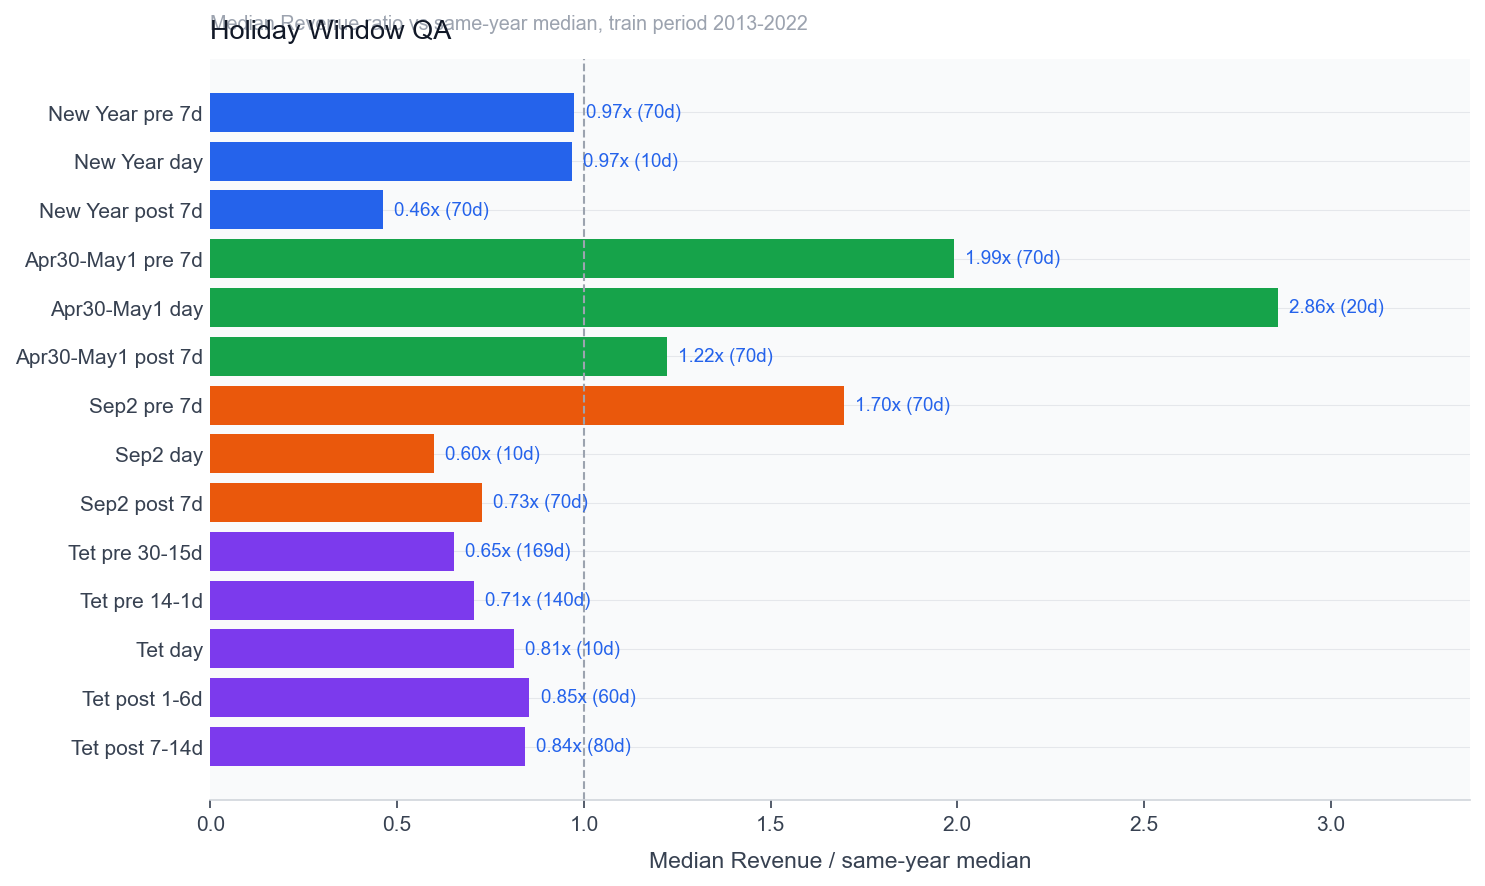

In [16]:
import sys
import matplotlib.pyplot as plt

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from theme import COLORS, CLR_MUTED, apply_theme, style_ax

apply_theme()

holiday_window_labels = {
    'New Year pre 7d': 'is_new_year_pre_7d',
    'New Year day': 'is_new_year',
    'New Year post 7d': 'is_new_year_post_7d',
    'Apr30-May1 pre 7d': 'is_apr30_may1_pre_7d',
    'Apr30-May1 day': 'is_apr30_may1',
    'Apr30-May1 post 7d': 'is_apr30_may1_post_7d',
    'Sep2 pre 7d': 'is_sep2_pre_7d',
    'Sep2 day': 'is_sep2',
    'Sep2 post 7d': 'is_sep2_post_7d',
    'Tet pre 30-15d': 'is_tet_pre_30_15d',
    'Tet pre 14-1d': 'is_tet_pre_14_1d',
    'Tet day': 'is_tet_day',
    'Tet post 1-6d': 'is_tet_post_1_6d',
    'Tet post 7-14d': 'is_tet_post_7_14d',
}

calendar_train = shared_calendar.merge(
    sales[['date', 'Revenue', 'COGS']],
    on='date',
    how='inner',
)
calendar_train = calendar_train[
    (calendar_train['date'] >= pd.Timestamp('2013-01-01'))
    & (calendar_train['date'] <= pd.Timestamp('2022-12-31'))
].copy()
calendar_train['year_revenue_median'] = calendar_train.groupby('year')['Revenue'].transform('median')
calendar_train['revenue_vs_year_median'] = (
    calendar_train['Revenue'] / calendar_train['year_revenue_median']
)

holiday_window_summary = pd.DataFrame([
    {
        'window': label,
        'feature': feature,
        'n_days': int(calendar_train[feature].sum()),
        'median_revenue_ratio': calendar_train.loc[
            calendar_train[feature] == 1,
            'revenue_vs_year_median',
        ].median(),
    }
    for label, feature in holiday_window_labels.items()
])
display(holiday_window_summary)

bar_colors = [
    COLORS['blue'], COLORS['blue'], COLORS['blue'],
    COLORS['emerald'], COLORS['emerald'], COLORS['emerald'],
    COLORS['flame'], COLORS['flame'], COLORS['flame'],
    COLORS['violet'], COLORS['violet'], COLORS['violet'], COLORS['violet'], COLORS['violet'],
]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    holiday_window_summary['window'],
    holiday_window_summary['median_revenue_ratio'],
    color=bar_colors,
)
ax.axvline(1.0, color=CLR_MUTED, linewidth=1.0, linestyle='--')
style_ax(
    ax,
    title='Holiday Window QA',
    subtitle='Median Revenue ratio vs same-year median, train period 2013-2022',
    xlabel='Median Revenue / same-year median',
)
ax.set_xlim(0, max(2.2, holiday_window_summary['median_revenue_ratio'].max() * 1.18))
ax.invert_yaxis()
for bar, ratio, n_days in zip(
    bars,
    holiday_window_summary['median_revenue_ratio'],
    holiday_window_summary['n_days'],
):
    ax.text(
        ratio + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'{ratio:.2f}x ({n_days}d)',
        va='center',
        ha='left',
        fontsize=9,
        color=COLORS['blue'],
    )
plt.tight_layout()
plt.show()


## 5. Train / Validation Split Skeleton

Chien luoc: Train full [2012-2022] voi weight cao hon cho 2019-2022.
Validation chi o 2020-2022 (4 folds, moi fold 6 thang).
KHONG dung cho modeling truc tiep — chi la skeleton de modeling notebook ke thua.


In [17]:
# ── Time-series CV folds ──
# Modeling notebook se import folds nay thay vi tu dinh nghia.
CV_FOLDS = [
    {'fold': 1, 'train_end': '2020-12-31', 'val_start': '2021-01-01', 'val_end': '2021-06-30'},
    {'fold': 2, 'train_end': '2021-06-30', 'val_start': '2021-07-01', 'val_end': '2021-12-31'},
    {'fold': 3, 'train_end': '2021-12-31', 'val_start': '2022-01-01', 'val_end': '2022-06-30'},
    {'fold': 4, 'train_end': '2022-06-30', 'val_start': '2022-07-01', 'val_end': '2022-12-31'},
]

# Sample weight: data gan hon duoc weight cao hon
# Cong thuc: w = 1 + alpha * (year - 2012) / 10
# alpha=1 -> 2012 weight=1.0, 2022 weight=2.0
WEIGHT_ALPHA = 1.0

def get_sample_weights(dates, alpha=WEIGHT_ALPHA):
    """Tra ve Series weight, year cang gan 2022 cang cao."""
    years = pd.to_datetime(dates).dt.year
    return 1 + alpha * (years - 2012) / 10

cv_folds_df = pd.DataFrame(CV_FOLDS)
cv_folds_df


,fold,train_end,val_start,val_end
0,1,2020-12-31,2021-01-01,2021-06-30
1,2,2021-06-30,2021-07-01,2021-12-31
2,3,2021-12-31,2022-01-01,2022-06-30
3,4,2022-06-30,2022-07-01,2022-12-31


## 6. Export

Notebook se co ghi parquet neu moi truong ho tro.
Neu khong, no se fallback sang pickle de tranh crash giua chung.


In [18]:
save_logs = [
    save_feature(shared_line_items, 'shared_line_items'),
    save_feature(shared_daily, 'shared_daily'),
    save_feature(shared_calendar, 'shared_calendar')
]

pd.DataFrame(save_logs)


,dataset,path,format
0,shared_line_items,D:\B. COMPUTER SCIENCE PROJECTS\D. DATATHON\Vi...,parquet
1,shared_daily,D:\B. COMPUTER SCIENCE PROJECTS\D. DATATHON\Vi...,parquet
2,shared_calendar,D:\B. COMPUTER SCIENCE PROJECTS\D. DATATHON\Vi...,parquet
